In [78]:
import numpy as np
import pandas as pd
import catboost
from catboost import CatBoostClassifier 
import sklearn
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc  
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns


In [79]:
dictionary=pd.read_csv(r'../TelcoChurn/data_dictionary.csv')
dictionary

,Acronyms,Description
0,CIRCLE_ID,Telecom circle area to which the customer belo...
1,LOC,Local calls within same telecom circle
2,STD,STD calls outside the calling circle
3,IC,Incoming calls
4,OG,Outgoing calls
5,T2T,Operator T to T ie within same operator mobile...
6,T2M,Operator T to other operator mobile
7,T2O,Operator T to other operator fixed line
8,T2F,Operator T to fixed lines of T
9,T2C,Operator T to its own call center


In [ ]:
train = pd.read_csv(r"../TelcoChurn/train.csv")
test = pd.read_csv(r"../TelcoChurn/test.csv")

train.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,...,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,...,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,...,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,...,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,...,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


In [81]:
train.info(verbose = True, show_counts = True)
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 172 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    id                        69999 non-null  int64  
 1    circle_id                 69999 non-null  int64  
 2    loc_og_t2o_mou            69297 non-null  float64
 3    std_og_t2o_mou            69297 non-null  float64
 4    loc_ic_t2o_mou            69297 non-null  float64
 5    last_date_of_month_6      69999 non-null  object 
 6    last_date_of_month_7      69600 non-null  object 
 7    last_date_of_month_8      69266 non-null  object 
 8    arpu_6                    69999 non-null  float64
 9    arpu_7                    69999 non-null  float64
 10   arpu_8                    69999 non-null  float64
 11   onnet_mou_6               67231 non-null  float64
 12   onnet_mou_7               67312 non-null  float64
 13   onnet_mou_8               66296 non-null  fl

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
count,69999.000000,69999.0,69297.0,69297.0,69297.0,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,...,69999.000000,69999.000000,17568.000000,17865.000000,18417.000000,69999.000000,69999.000000,69999.000000,69999.00000,69999.000000
mean,34999.000000,109.0,0.0,0.0,0.0,283.134365,278.185912,278.858826,133.153275,133.894438,...,0.081444,0.085487,0.916325,0.909544,0.890319,1220.639709,68.108597,65.935830,60.07674,0.101887
std,20207.115084,0.0,0.0,0.0,0.0,334.213918,344.366927,351.924315,299.963093,311.277193,...,0.634547,0.680035,0.276907,0.286842,0.312501,952.426321,269.328659,267.899034,257.22681,0.302502
min,0.000000,109.0,0.0,0.0,0.0,-2258.709000,-1289.715000,-945.808000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000,0.000000,0.000000,0.00000,0.000000
25%,17499.500000,109.0,0.0,0.0,0.0,93.581000,86.714000,84.095000,7.410000,6.675000,...,0.000000,0.000000,1.000000,1.000000,1.000000,468.000000,0.000000,0.000000,0.00000,0.000000
50%,34999.000000,109.0,0.0,0.0,0.0,197.484000,191.588000,192.234000,34.110000,32.280000,...,0.000000,0.000000,1.000000,1.000000,1.000000,868.000000,0.000000,0.000000,0.00000,0.000000
75%,52498.500000,109.0,0.0,0.0,0.0,370.791000,365.369500,369.909000,119.390000,115.837500,...,0.000000,0.000000,1.000000,1.000000,1.000000,1813.000000,0.000000,0.000000,0.00000,0.000000
max,69998.000000,109.0,0.0,0.0,0.0,27731.088000,35145.834000,33543.624000,7376.710000,8157.780000,...,33.000000,41.000000,1.000000,1.000000,1.000000,4337.000000,12916.220000,9165.600000,11166.21000,1.000000


Null Data


--- Pengecekan Missing Values ---
Fitur dengan persentase nilai hilang terbesar:
max_rech_data_6             74.902499
fb_user_6                   74.902499
date_of_last_rech_data_6    74.902499
av_rech_amt_data_6          74.902499
night_pck_user_6            74.902499
count_rech_2g_6             74.902499
total_rech_data_6           74.902499
arpu_2g_6                   74.902499
count_rech_3g_6             74.902499
arpu_3g_6                   74.902499
arpu_3g_7                   74.478207
count_rech_2g_7             74.478207
av_rech_amt_data_7          74.478207
max_rech_data_7             74.478207
total_rech_data_7           74.478207
arpu_2g_7                   74.478207
date_of_last_rech_data_7    74.478207
night_pck_user_7            74.478207
fb_user_7                   74.478207
count_rech_3g_7             74.478207
total_rech_data_8           73.689624
max_rech_data_8             73.689624
date_of_last_rech_data_8    73.689624
count_rech_2g_8             73.689624
fb_use

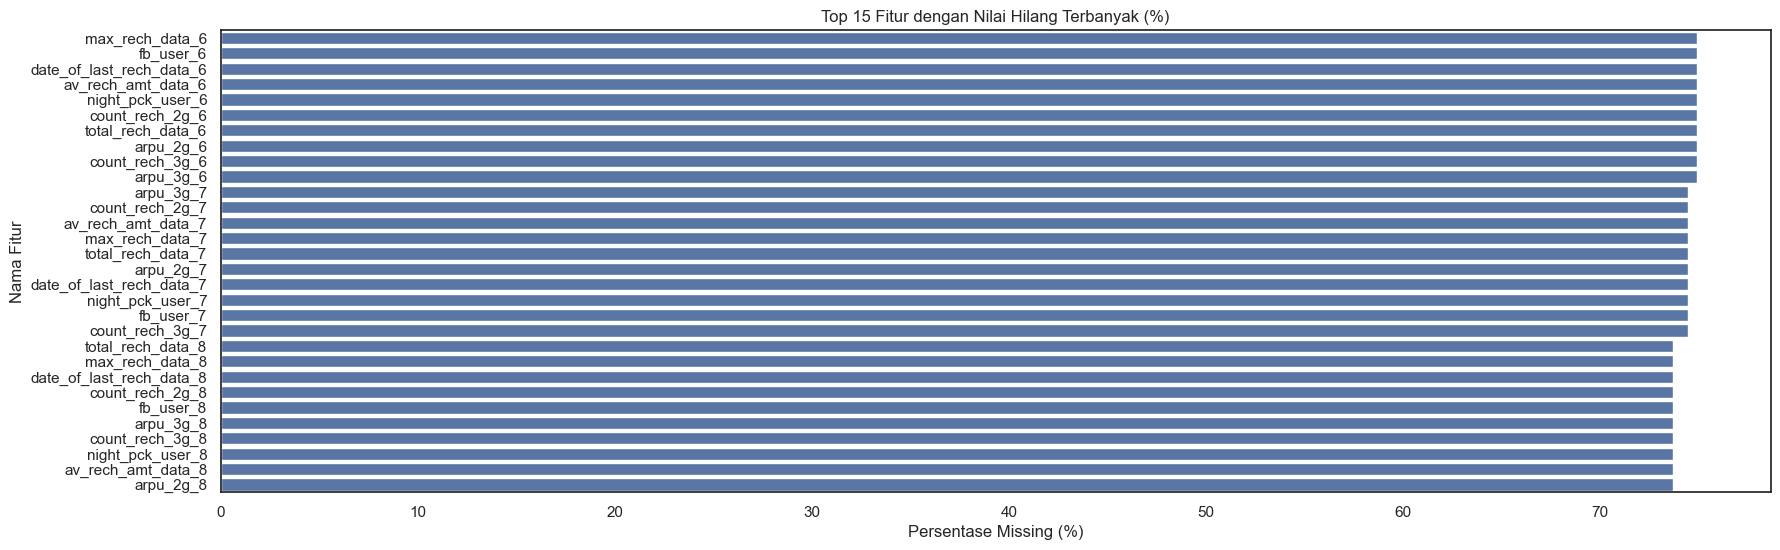

In [114]:
print("\n--- Pengecekan Missing Values ---")
missing_percentages = (train.isnull().sum() / len(train)) * 100
missing_features = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

print("Fitur dengan persentase nilai hilang terbesar:")
print(missing_features.head(30))

# Visualisasi Missing Values
plt.figure(figsize=(20, 6))
sns.barplot(x=missing_features.head(30).values, y=missing_features.head(30).index)
plt.title('Top 15 Fitur dengan Nilai Hilang Terbanyak (%)')
plt.xlabel('Persentase Missing (%)')
plt.ylabel('Nama Fitur')
plt.show()

Data Imbalance

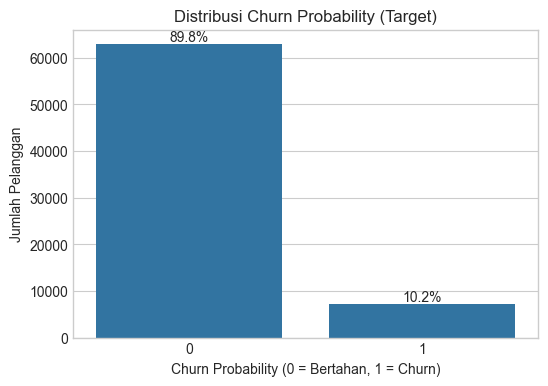

In [83]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x='churn_probability')
plt.title('Distribusi Churn Probability (Target)')
plt.xlabel('Churn Probability (0 = Bertahan, 1 = Churn)')
plt.ylabel('Jumlah Pelanggan')

# Menambahkan persentase di atas bar
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

Analisis Tren Perilaku Pelanggan (Bulan 6, 7, 8)

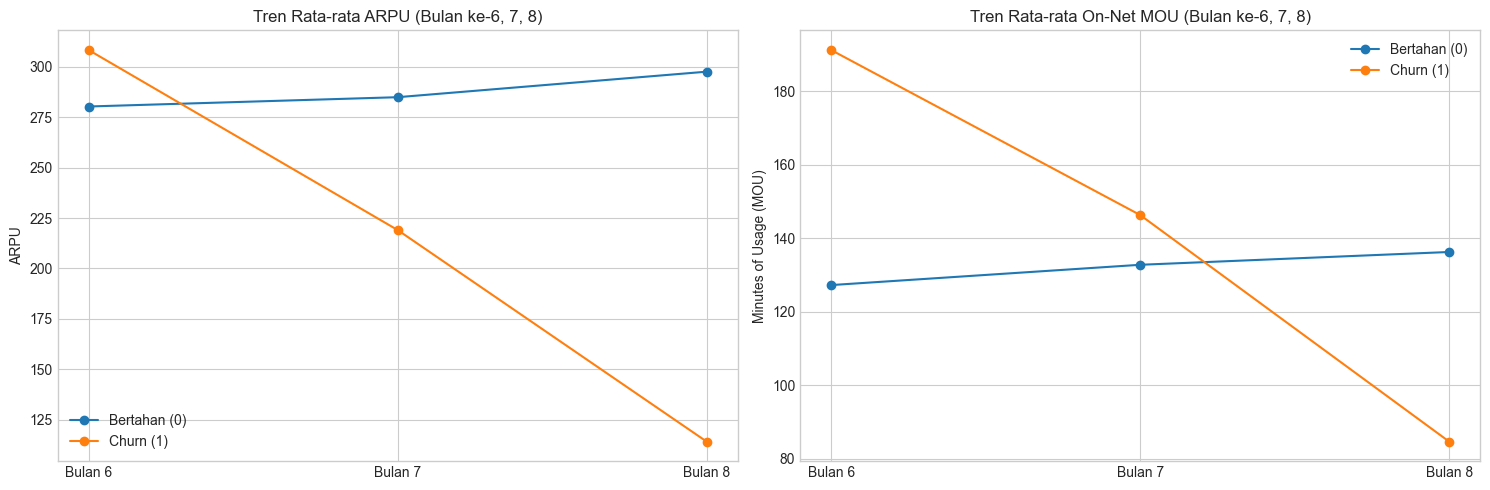

In [ ]:
arpu_cols = ['arpu_6', 'arpu_7', 'arpu_8']
mou_cols = ['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8']

churn_arpu_trend = train.groupby('churn_probability')[arpu_cols].mean().T
churn_mou_trend = train.groupby('churn_probability')[mou_cols].mean().T

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Tren ARPU
churn_arpu_trend.plot(kind='line', marker='o', ax=axes[0])
axes[0].set_title('Tren Rata-rata ARPU (Bulan ke-6, 7, 8)')
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Bulan 6', 'Bulan 7', 'Bulan 8'])
axes[0].set_ylabel('ARPU')
axes[0].legend(['Bertahan (0)', 'Churn (1)'])

# Plot Tren ONNET MOU
churn_mou_trend.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title('Tren Rata-rata On-Net MOU (Bulan ke-6, 7, 8)')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Bulan 6', 'Bulan 7', 'Bulan 8'])
axes[1].set_ylabel('Minutes of Usage (MOU)')
axes[1].legend(['Bertahan (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()

Korelasi


--- Menghitung Matriks Korelasi ---
25 Fitur dengan Korelasi Tertinggi terhadap Churn:
churn_probability     1.000000
total_ic_mou_8        0.187566
total_rech_num_8      0.167043
total_rech_amt_8      0.160455
max_rech_amt_8        0.159131
arpu_8                0.157566
total_og_mou_8        0.149325
last_day_rch_amt_8    0.139611
aon                   0.135177
loc_ic_mou_8          0.128784
loc_ic_t2m_mou_8      0.124840
total_ic_mou_7        0.120197
loc_og_t2m_mou_8      0.113309
loc_og_mou_8          0.108821
std_og_mou_6          0.107870
loc_ic_t2m_mou_7      0.099544
roam_og_mou_8         0.098703
loc_ic_mou_7          0.098318
loc_og_t2m_mou_7      0.088988
loc_og_mou_7          0.087851
roam_og_mou_7         0.086646
roam_ic_mou_8         0.085761
std_og_t2t_mou_6      0.084323
std_og_t2m_mou_6      0.081825
monthly_2g_8          0.076254
max_rech_amt_7        0.073366
Name: churn_probability, dtype: float64


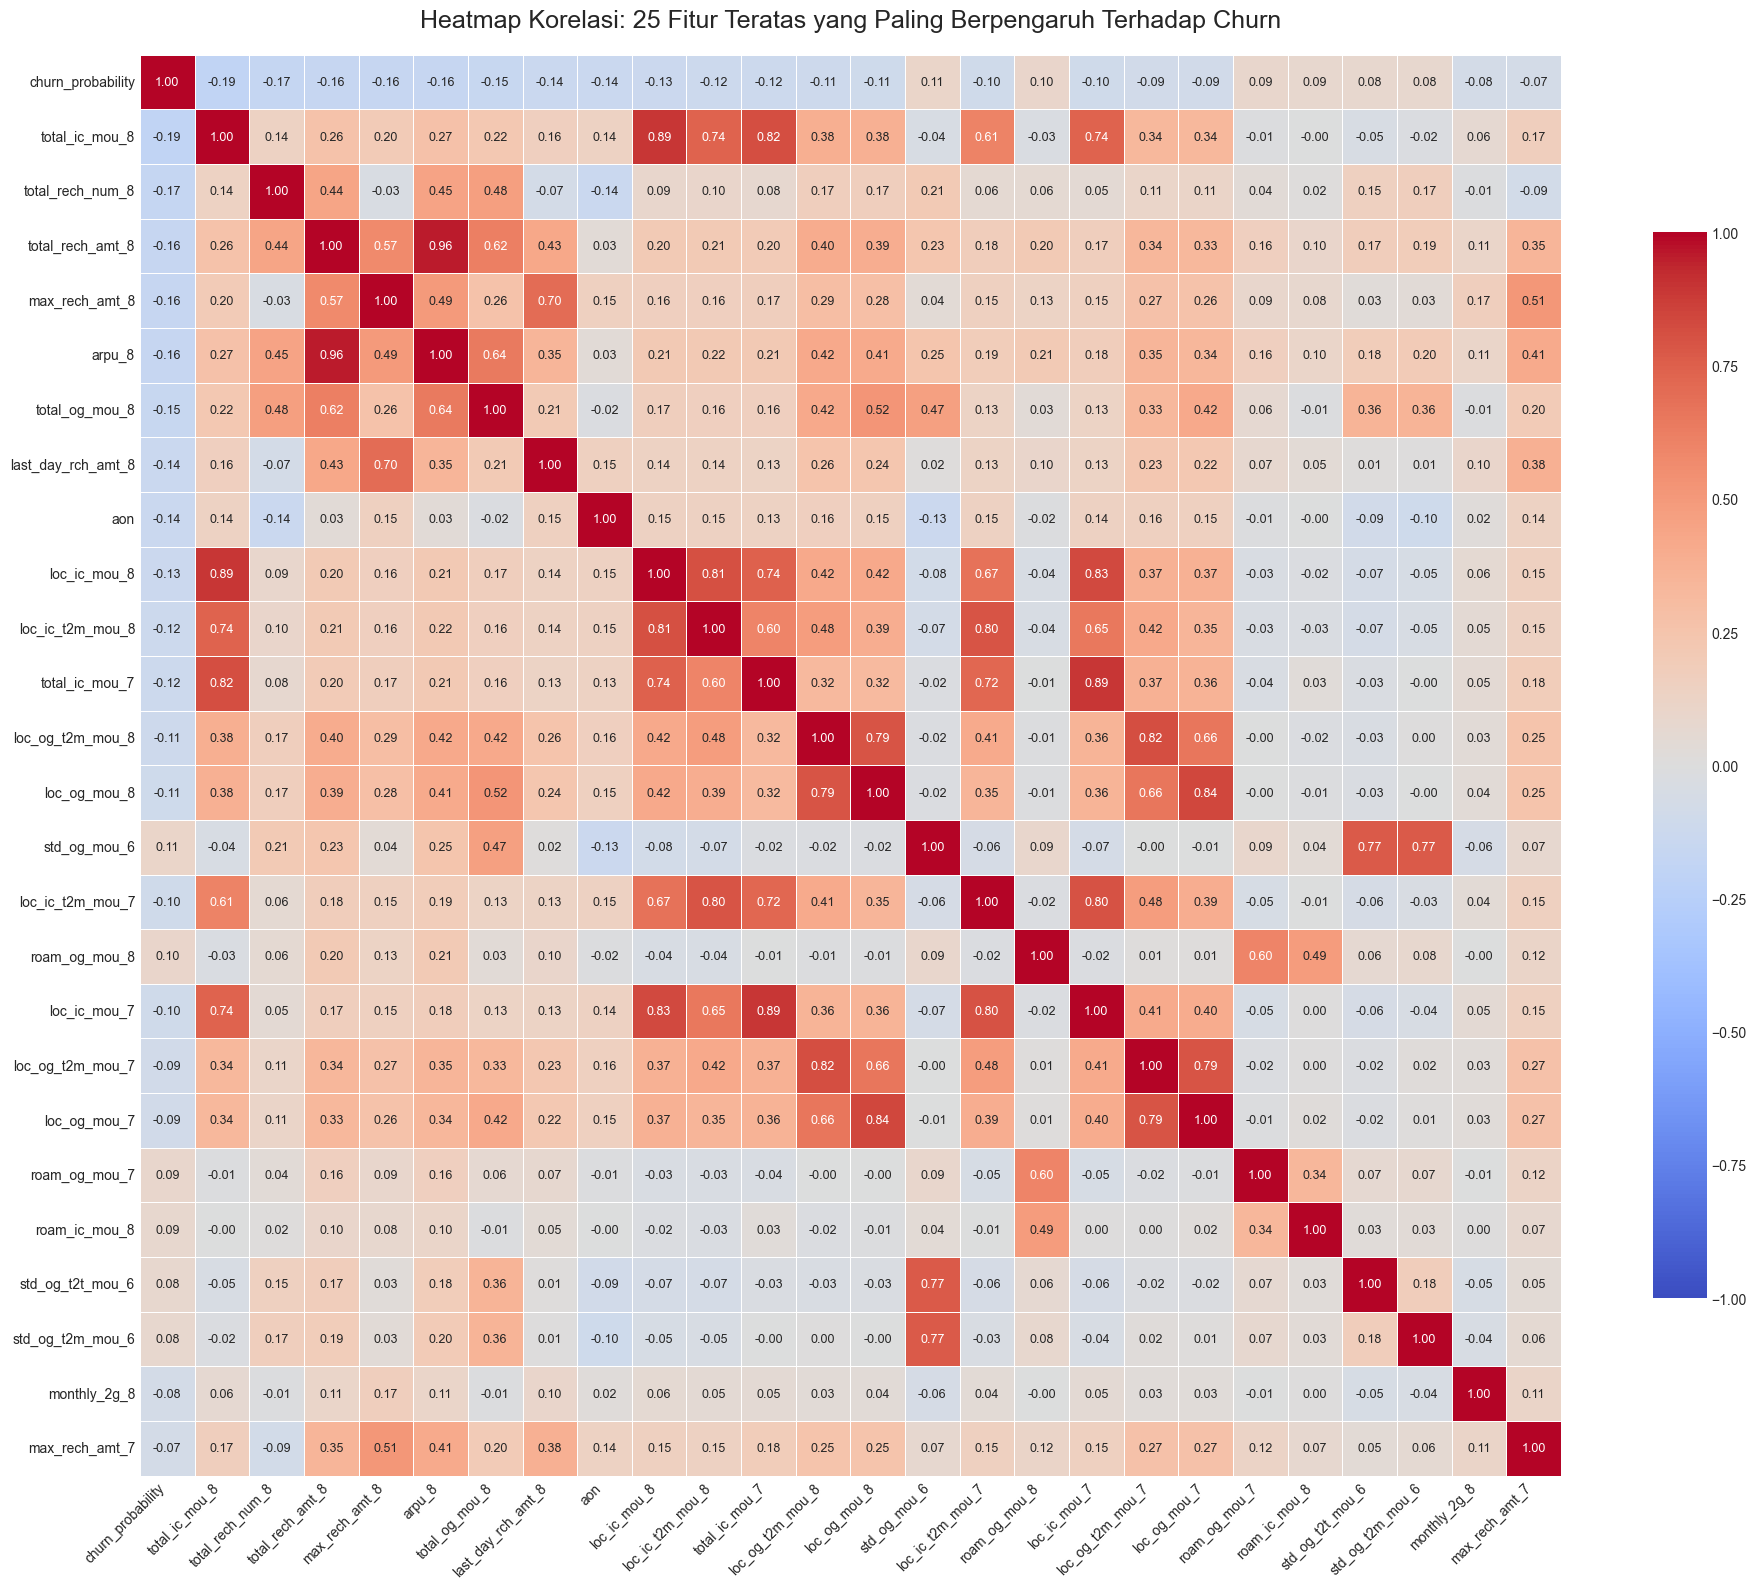

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
print("\n--- Menghitung Matriks Korelasi ---")
numeric_train = train.select_dtypes(include=['number'])
correlation_with_target = numeric_train.corr()['churn_probability'].abs().sort_values(ascending=False)
top_25_features = correlation_with_target.index[:26] 

print("25 Fitur dengan Korelasi Tertinggi terhadap Churn:")
print(correlation_with_target.head(26))
top_25_train = train[top_25_features]
top_25_corr = top_25_train.corr()
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(top_25_corr, dtype=bool))

# Plot heatmap
sns.heatmap(
    top_25_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    annot_kws={"size": 9} 
)

plt.title('Heatmap Korelasi: 25 Fitur Teratas yang Paling Berpengaruh Terhadap Churn', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Data Imputation

In [ ]:
def preprocess_telecom_data(train, is_train=True):
    """
    Fungsi untuk membersihkan dan memproses dataset telecom churn.
    """
    data = train.copy()
    cols_to_drop = ['id', 'circle_id']
    
    # Hapus kolom tanggal (fokus pada data numerik & kategori perilaku)
    date_cols = [c for c in data.columns if 'date' in c]
    cols_to_drop.extend(date_cols)
    
    # Hapus kolom yang isinya hanya 1 nilai unik (zero variance)
    single_value_cols = [c for c in data.columns if data[c].nunique() <= 1]
    cols_to_drop.extend(single_value_cols)
    
    # Lakukan drop hanya untuk kolom yang memang ada di dataframe
    cols_to_drop = list(set(cols_to_drop).intersection(data.columns))
    data = data.drop(columns=cols_to_drop)
    
    # --- B. Penanganan Missing Values (Imputasi Berbasis Bisnis) ---
    
    # 1. Kolom Paket Data dan Internet (Isi NaN dengan 0)
    # Jika NaN berarti pelanggan tidak beli paket internet
    data_recharge_cols = [
        'total_rech_data_6', 'total_rech_data_7', 'total_rech_data_8',
        'max_rech_data_6', 'max_rech_data_7', 'max_rech_data_8',
        'count_rech_2g_6', 'count_rech_2g_7', 'count_rech_2g_8',
        'count_rech_3g_6', 'count_rech_3g_7', 'count_rech_3g_8',
        'av_rech_amt_data_6', 'av_rech_amt_data_7', 'av_rech_amt_data_8',
        'arpu_3g_6', 'arpu_3g_7', 'arpu_3g_8',
        'arpu_2g_6', 'arpu_2g_7', 'arpu_2g_8'
    ]
    for col in data_recharge_cols:
        if col in data.columns:
            data[col] = data[col].fillna(0)
            
    # 2. Kolom Flag / Kategorikal (Isi NaN dengan -1)
    # Nilai asli adalah 1 dan 0. Kita jadikan -1 sebagai kategori "Tidak Langganan"
    cat_cols = [
        'night_pck_user_6', 'night_pck_user_7', 'night_pck_user_8',
        'fb_user_6', 'fb_user_7', 'fb_user_8'
    ]
    for col in cat_cols:
        if col in data.columns:
            data[col] = data[col].fillna(-1).astype(int)
            
    # 3. Fitur Numerik Lainnya (seperti MOU - Minutes of Usage) 
    # Jika kosong, asumsikan tidak ada penggunaan telepon (isi 0)
    numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
    # Jangan imputasi kolom target (churn_probability) jika ada
    if 'churn_probability' in numeric_cols:
        numeric_cols = numeric_cols.drop('churn_probability')
        
    data[numeric_cols] = data[numeric_cols].fillna(0)
    
    # --- C. Feature Engineering (Menangkap Tren Penurunan) ---
    
    # 1. Total Tagihan (ARPU: Average Revenue Per User)
    if all(c in data.columns for c in ['arpu_6', 'arpu_7', 'arpu_8']):
        data['avg_arpu_6_7'] = (data['arpu_6'] + data['arpu_7']) / 2
        data['diff_arpu_8'] = data['arpu_8'] - data['avg_arpu_6_7']
        
    # 2. Total Penggunaan Telepon (MOU)
    # Total MOU = Onnet + Offnet
    for m in ['6', '7', '8']:
        if f'onnet_mou_{m}' in data.columns and f'offnet_mou_{m}' in data.columns:
            data[f'total_mou_{m}'] = data[f'onnet_mou_{m}'] + data[f'offnet_mou_{m}']
            
    if all(c in data.columns for c in ['total_mou_6', 'total_mou_7', 'total_mou_8']):
        data['avg_mou_6_7'] = (data['total_mou_6'] + data['total_mou_7']) / 2
        data['diff_mou_8'] = data['total_mou_8'] - data['avg_mou_6_7']
        
    # 3. Total Isi Ulang Pulsa (Recharge Amount)
    if all(c in data.columns for c in ['total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8']):
        data['avg_rech_amt_6_7'] = (data['total_rech_amt_6'] + data['total_rech_amt_7']) / 2
        data['diff_rech_amt_8'] = data['total_rech_amt_8'] - data['avg_rech_amt_6_7']

    # 4. Total Isi Ulang Data (Recharge Data)
    if all(c in data.columns for c in ['total_rech_data_6', 'total_rech_data_7', 'total_rech_data_8']):
        data['avg_rech_data_6_7'] = (data['total_rech_data_6'] + data['total_rech_data_7']) / 2
        data['diff_rech_data_8'] = data['total_rech_data_8'] - data['avg_rech_data_6_7']

    return data

train_clean = preprocess_telecom_data(train, is_train=True)
test_clean = preprocess_telecom_data(test, is_train=False)

print(f"Dimensi Train mentah : {train.shape}")
print(f"Dimensi Train bersih : {train_clean.shape}")
print(f"Dimensi Test mentah  : {test.shape}")
print(f"Dimensi Test bersih  : {test_clean.shape}")

print(f"\nJumlah nilai NaN di Train bersih: {train_clean.isnull().sum().sum()}")
print(f"Jumlah nilai NaN di Test bersih : {test_clean.isnull().sum().sum()}")

X = train_clean.drop(columns=['churn_probability'])
y = train_clean['churn_probability']
X_test = test_clean 

categorical_features_names = [
    'night_pck_user_6', 'night_pck_user_7', 'night_pck_user_8',
    'fb_user_6', 'fb_user_7', 'fb_user_8'
]
cat_features = [col for col in categorical_features_names if col in X.columns]



--- Memproses Data ---


C:\Users\USER\AppData\Local\Temp\ipykernel_31764\3214088312.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['avg_arpu_6_7'] = (data['arpu_6'] + data['arpu_7']) / 2
C:\Users\USER\AppData\Local\Temp\ipykernel_31764\3214088312.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['diff_arpu_8'] = data['arpu_8'] - data['avg_arpu_6_7']
C:\Users\USER\AppData\Local\Temp\ipykernel_31764\3214088312.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

Dimensi Train mentah : (69999, 172)
Dimensi Train bersih : (69999, 163)
Dimensi Test mentah  : (30000, 171)
Dimensi Test bersih  : (30000, 162)

Jumlah nilai NaN di Train bersih: 0
Jumlah nilai NaN di Test bersih : 0

--- Data Siap Digunakan untuk Modeling CatBoost ---
Fitur Kategori untuk model: ['night_pck_user_6', 'night_pck_user_7', 'night_pck_user_8', 'fb_user_6', 'fb_user_7', 'fb_user_8']


C:\Users\USER\AppData\Local\Temp\ipykernel_31764\3214088312.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['avg_arpu_6_7'] = (data['arpu_6'] + data['arpu_7']) / 2
C:\Users\USER\AppData\Local\Temp\ipykernel_31764\3214088312.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['diff_arpu_8'] = data['arpu_8'] - data['avg_arpu_6_7']
C:\Users\USER\AppData\Local\Temp\ipykernel_31764\3214088312.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh

In [ ]:
from imblearn.over_sampling import SMOTENC

cat_indices = [X.columns.get_loc(col) for col in cat_features]

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)

print("Jumlah target sebelum SMOTE:")
print(y.value_counts())

# Melakukan balancing data
X_resampled, y_resampled = smote_nc.fit_resample(X, y)
print("\nJumlah target setelah SMOTE:")
print(y_resampled.value_counts())

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nDistribusi target pada Data Latih:\n{y_train.value_counts(normalize=True)}")

Jumlah target sebelum SMOTE:
churn_probability
0    62867
1     7132
Name: count, dtype: int64

Jumlah target setelah SMOTE:
churn_probability
0    62867
1    62867
Name: count, dtype: int64

Distribusi target pada Data Latih:
churn_probability
0    0.89812
1    0.10188
Name: proportion, dtype: float64


In [ ]:
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=4,
    eval_metric='AUC',
    custom_metric=['AUC'],
    auto_class_weights='Balanced', 
    cat_features=cat_features,
    random_seed=42,
    early_stopping_rounds=100, 
    verbose=100 
)

# Melatih model dengan data validasi
cb_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	test: 0.8859375	best: 0.8859375 (0)	total: 95.1ms	remaining: 1m 34s
100:	test: 0.9365193	best: 0.9365193 (100)	total: 9.03s	remaining: 1m 20s
200:	test: 0.9392915	best: 0.9392915 (200)	total: 17.4s	remaining: 1m 9s
300:	test: 0.9408930	best: 0.9408930 (300)	total: 25.8s	remaining: 59.8s
400:	test: 0.9414413	best: 0.9414416 (399)	total: 34.2s	remaining: 51.2s
500:	test: 0.9416565	best: 0.9416646 (472)	total: 42.6s	remaining: 42.4s
600:	test: 0.9418754	best: 0.9420037 (578)	total: 51s	remaining: 33.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9420037462
bestIteration = 578

Shrink model to first 579 iterations.


In [89]:
print("\n--- Evaluasi Model di Data Validasi ---")
y_pred_val = cb_model.predict(X_val)
y_pred_proba_val = cb_model.predict_proba(X_val)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_val, y_pred_proba_val))
print("\nClassification Report:\n", classification_report(y_val, y_pred_val))


--- Evaluasi Model di Data Validasi ---
ROC-AUC Score: 0.9420037462463207

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.95     18860
           1       0.52      0.83      0.64      2140

    accuracy                           0.91     21000
   macro avg       0.75      0.87      0.79     21000
weighted avg       0.93      0.91      0.91     21000



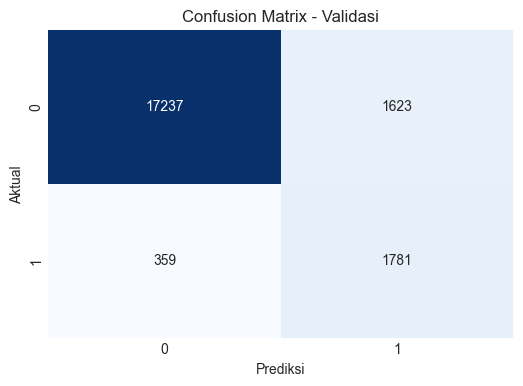

In [90]:
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Validasi')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

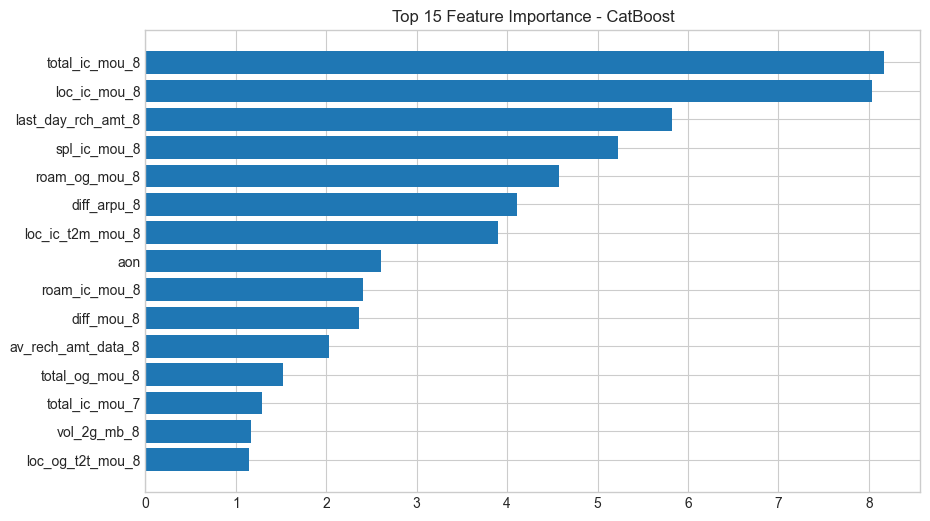

In [91]:
feature_importance = cb_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('Top 15 Feature Importance - CatBoost')
plt.show()

--- Pengecekan Overfitting (Numerik) ---
ROC-AUC Score Data Latih    : 0.9667
ROC-AUC Score Data Validasi : 0.9420
Selisih (Gap)               : 0.0247
-> GOOD FIT: Model sangat seimbang dan generalisasinya baik!

--- Visualisasi Grafik Belajar (Learning Curve) ---
Metrik yang terekam di Data Latih: ['Logloss']
Metrik yang terekam di Data Validasi: ['Logloss', 'AUC']


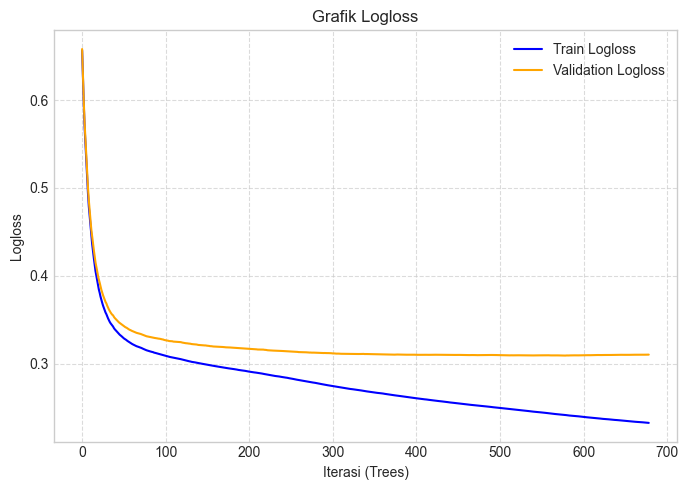

In [ ]:
print("--- Pengecekan Overfitting (Numerik) ---")

# Prediksi probabilitas di data Latih
y_train_pred_proba = cb_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred_proba)

# Prediksi probabilitas di data Validasi (sudah dilakukan sebelumnya, kita panggil lagi)
y_val_pred_proba = cb_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"ROC-AUC Score Data Latih    : {train_auc:.4f}")
print(f"ROC-AUC Score Data Validasi : {val_auc:.4f}")

# Menghitung selisih (Gap)
gap = train_auc - val_auc
print(f"Selisih (Gap)               : {gap:.4f}")

if gap > 0.05:
    print("-> Indikasi OVERFITTING: Model terlalu menghafal data latih!")
elif gap < 0:
    print("-> Indikasi UNDERFITTING: Ada yang salah dengan pembagian data.")
else:
    print("-> GOOD FIT: Model sangat seimbang dan generalisasinya baik!")

import matplotlib.pyplot as plt

print("\n--- Visualisasi Grafik Belajar (Learning Curve) ---")

# Mengambil histori nilai metrik dari CatBoost
evals_result = cb_model.get_evals_result()

learn_metrics = list(evals_result['learn'].keys())
val_metrics = list(evals_result['validation'].keys())

print(f"Metrik yang terekam di Data Latih: {learn_metrics}")
print(f"Metrik yang terekam di Data Validasi: {val_metrics}")

num_metrics = len(learn_metrics)
fig, axes = plt.subplots(1, num_metrics, figsize=(7 * num_metrics, 5))

if num_metrics == 1:
    axes = [axes]

for i, metric_name in enumerate(learn_metrics):
    axes[i].plot(evals_result['learn'][metric_name], label=f'Train {metric_name}', color='blue')
    
    if metric_name in val_metrics:
        axes[i].plot(evals_result['validation'][metric_name], label=f'Validation {metric_name}', color='orange')
        
    axes[i].set_title(f'Grafik {metric_name}')
    axes[i].set_xlabel('Iterasi (Trees)')
    axes[i].set_ylabel(metric_name)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Memulai 5-Fold Cross Validation ---

Fold ke-1...
  Train AUC      : 0.9764
  Validation AUC : 0.9445

Fold ke-2...
  Train AUC      : 0.9694
  Validation AUC : 0.9472

Fold ke-3...
  Train AUC      : 0.9675
  Validation AUC : 0.9475

Fold ke-4...
  Train AUC      : 0.9612
  Validation AUC : 0.9419

Fold ke-5...
  Train AUC      : 0.9770
  Validation AUC : 0.9434

HASIL AKHIR CROSS VALIDATION (Rata-rata):
Rata-rata Train AUC      : 0.9703
Rata-rata Validation AUC : 0.9449
Selisih (Gap)            : 0.0254

-> KESIMPULAN: GOOD FIT! Model sangat stabil dan generalisasinya kuat di semua skenario.


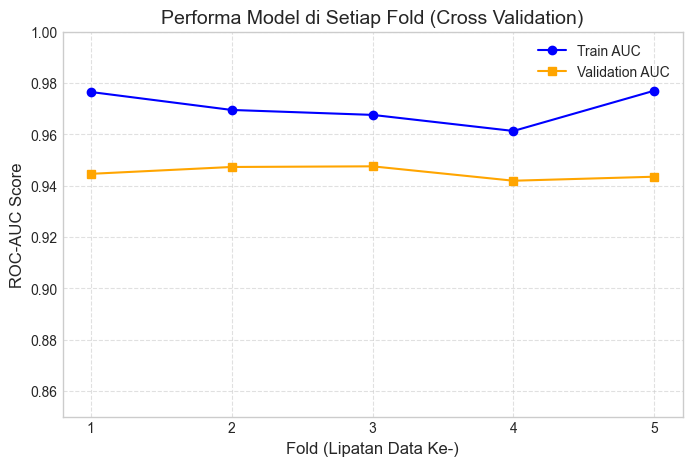

In [ ]:
n_splits = 5 
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_auc_scores = []
val_auc_scores = []

print(f"--- Memulai {n_splits}-Fold Cross Validation ---")


# Looping Pelatihan & Evaluasi per Fold
fold = 1
for train_idx, val_idx in skf.split(X, y):
    print(f"\nFold ke-{fold}...")

    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='AUC',
        auto_class_weights='Balanced',
        cat_features=cat_features,
        random_seed=42,
        early_stopping_rounds=50,
        verbose=False 
    )

    model_cv.fit(X_train_cv, y_train_cv, eval_set=(X_val_cv, y_val_cv), use_best_model=True)

    y_train_pred = model_cv.predict_proba(X_train_cv)[:, 1]
    y_val_pred = model_cv.predict_proba(X_val_cv)[:, 1]

    train_auc = roc_auc_score(y_train_cv, y_train_pred)
    val_auc = roc_auc_score(y_val_cv, y_val_pred)

    train_auc_scores.append(train_auc)
    val_auc_scores.append(val_auc)
    
    print(f"  Train AUC      : {train_auc:.4f}")
    print(f"  Validation AUC : {val_auc:.4f}")
    
    fold += 1

mean_train_auc = np.mean(train_auc_scores)
mean_val_auc = np.mean(val_auc_scores)
gap = mean_train_auc - mean_val_auc

print("\n==========================================")
print("HASIL AKHIR CROSS VALIDATION (Rata-rata):")
print("==========================================")
print(f"Rata-rata Train AUC      : {mean_train_auc:.4f}")
print(f"Rata-rata Validation AUC : {mean_val_auc:.4f}")
print(f"Selisih (Gap)            : {gap:.4f}")

if gap > 0.05:
    print("\n-> KESIMPULAN: Indikasi OVERFITTING kuat! Model terlalu menghafal data latih.")
elif gap < 0:
    print("\n-> KESIMPULAN: Indikasi UNDERFITTING! (Skor validasi lebih tinggi, biasanya karena data error).")
else:
    print("\n-> KESIMPULAN: GOOD FIT! Model sangat stabil dan generalisasinya kuat di semua skenario.")

# Visualisasi Kestabilan Model

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_splits+1), train_auc_scores, label='Train AUC', marker='o', color='blue')
plt.plot(range(1, n_splits+1), val_auc_scores, label='Validation AUC', marker='s', color='orange')

plt.title('Performa Model di Setiap Fold (Cross Validation)', fontsize=14)
plt.xlabel('Fold (Lipatan Data Ke-)', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xticks(range(1, n_splits+1))
plt.ylim(0.85, 1.0) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()